In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
data = pd.read_csv("/content/drive/MyDrive/trum_tweet_sentiment_analysis.csv")

print(data.head())
print(data.info())
print(data["Sentiment"].value_counts())

                                                text  Sentiment
0  RT @JohnLeguizamo: #trump not draining swamp b...          0
1  ICYMI: Hackers Rig FM Radio Stations To Play A...          0
2  Trump protests: LGBTQ rally in New York https:...          1
3  "Hi I'm Piers Morgan. David Beckham is awful b...          0
4  RT @GlennFranco68: Tech Firm Suing BuzzFeed fo...          0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1850123 entries, 0 to 1850122
Data columns (total 2 columns):
 #   Column     Dtype 
---  ------     ----- 
 0   text       object
 1   Sentiment  int64 
dtypes: int64(1), object(1)
memory usage: 28.2+ MB
None
Sentiment
0    1244211
1     605912
Name: count, dtype: int64


In [5]:
print(data.isnull().sum())

text         0
Sentiment    0
dtype: int64


In [6]:
def preprocess_text(text):
    text = str(text)              # Convert input to string
    text = text.lower()           # Lowercase text

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", "", text, flags=re.MULTILINE)

    # Remove @mentions and hashtag symbol
    text = re.sub(r"\@\w+|\#", "", text)

    # Remove punctuation and special characters
    text = re.sub(r"[^\w\s]", "", text)

    # Remove numbers
    text = re.sub(r"\d+", "", text)

    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()

    # Remove stopwords and apply lemmatization
    stop_words = set(stopwords.words("english"))
    lemmatizer = WordNetLemmatizer()

    tokens = text.split()

    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens if word not in stop_words
    ]

    return " ".join(tokens)

In [7]:
data["cleaned_text"] = data["text"].apply(preprocess_text)

print(data[["text", "cleaned_text", "Sentiment"]].head())

                                                text  \
0  RT @JohnLeguizamo: #trump not draining swamp b...   
1  ICYMI: Hackers Rig FM Radio Stations To Play A...   
2  Trump protests: LGBTQ rally in New York https:...   
3  "Hi I'm Piers Morgan. David Beckham is awful b...   
4  RT @GlennFranco68: Tech Firm Suing BuzzFeed fo...   

                                        cleaned_text  Sentiment  
0  rt trump draining swamp taxpayer dollar trip a...          0  
1  icymi hacker rig fm radio station play antitru...          0  
2    trump protest lgbtq rally new york bbcworld via          1  
3  hi im pier morgan david beckham awful donald t...          0  
4  rt tech firm suing buzzfeed publishing unverif...          0  


In [8]:
X = data["cleaned_text"]
y = data["Sentiment"]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [10]:
vocab_size = 10000
oov_token = "<OOV>"

tokenizer = Tokenizer(
    num_words=vocab_size,
    oov_token=oov_token
)

tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [11]:
seq_lengths = [len(seq) for seq in X_train_seq]

max_len = int(np.percentile(seq_lengths, 95))

print("95th percentile max length:", max_len)

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_len,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_len,
    padding="post",
    truncating="post"
)

95th percentile max length: 16


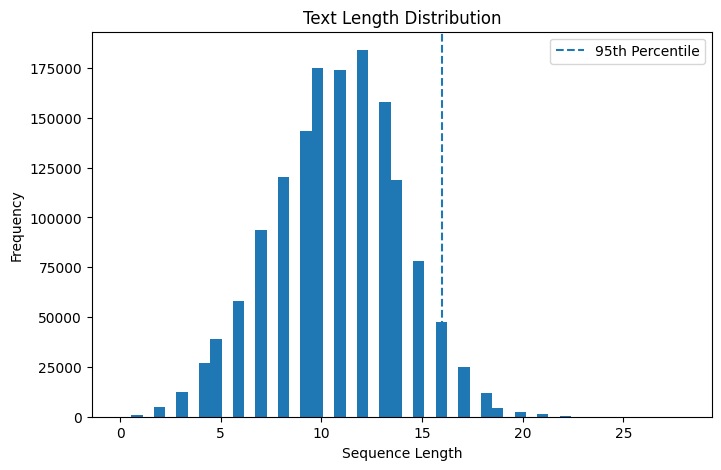

In [12]:
plt.figure(figsize=(8, 5))
plt.hist(seq_lengths, bins=50)
plt.axvline(
    np.percentile(seq_lengths, 95),
    linestyle="dashed",
    label="95th Percentile"
)
plt.title("Text Length Distribution")
plt.xlabel("Sequence Length")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [13]:
embedding_dim = 128
rnn_units = 64

rnn_model = Sequential()

rnn_model.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        input_length=max_len
    )
)

rnn_model.add(SimpleRNN(rnn_units))

rnn_model.add(Dense(1, activation="sigmoid"))

rnn_model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

rnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [14]:
lstm_model = Sequential()

lstm_model.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        input_length=max_len
    )
)

lstm_model.add(LSTM(64))

lstm_model.add(Dense(1, activation="sigmoid"))

lstm_model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [15]:
rnn_checkpoint = ModelCheckpoint(
    "best_rnn_model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

rnn_history = rnn_model.fit(
    X_train_pad,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    callbacks=[rnn_checkpoint, early_stop]
)

Epoch 1/10
18502/18502 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9145 - loss: 0.2119
Epoch 1: val_accuracy improved from None to 0.95554, saving model to best_rnn_model.h5



Epoch 1: finished saving model to best_rnn_model.h5
18502/18502 ━━━━━━━━━━━━━━━━━━━━ 100s 5ms/step - accuracy: 0.9386 - loss: 0.1626 - val_accuracy: 0.9555 - val_loss: 0.1249
Epoch 2/10
18493/18502 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9629 - loss: 0.1060
Epoch 2: val_accuracy improved from 0.95554 to 0.96064, saving model to best_rnn_model.h5



Epoch 2: finished saving model to best_rnn_model.h5
18502/18502 ━━━━━━━━━━━━━━━━━━━━ 91s 5ms/step - accuracy: 0.9635 - loss: 0.1053 - val_accuracy: 0.9606 - val_loss: 0.1133
Epoch 3/10
18494/18502 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9705 - loss: 0.0860
Epoch 3: val_accuracy improved from 0.96064 to 0.96168, saving model to best_rnn_model.h5



Epoch 3: finished saving model to best_rnn_model.h5
18502/18502 ━━━━━━━━━━━━━━━━━━━━ 98s 5ms/step - accuracy: 0.9695 - loss: 0.0891 - val_accuracy: 0.9617 - val_loss: 0.1105
Epoch 4/10
18495/18502 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9738 - loss: 0.0771
Epoch 4: val_accuracy improved from 0.96168 to 0.96378, saving model to best_rnn_model.h5



Epoch 4: finished saving model to best_rnn_model.h5
18502/18502 ━━━━━━━━━━━━━━━━━━━━ 90s 5ms/step - accuracy: 0.9726 - loss: 0.0803 - val_accuracy: 0.9638 - val_loss: 0.1113
Epoch 5/10
18491/18502 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9764 - loss: 0.0706
Epoch 5: val_accuracy improved from 0.96378 to 0.96441, saving model to best_rnn_model.h5



Epoch 5: finished saving model to best_rnn_model.h5
18502/18502 ━━━━━━━━━━━━━━━━━━━━ 143s 5ms/step - accuracy: 0.9750 - loss: 0.0746 - val_accuracy: 0.9644 - val_loss: 0.1098
Epoch 6/10
18501/18502 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9773 - loss: 0.0672
Epoch 6: val_accuracy did not improve from 0.96441
18502/18502 ━━━━━━━━━━━━━━━━━━━━ 92s 5ms/step - accuracy: 0.9759 - loss: 0.0714 - val_accuracy: 0.9618 - val_loss: 0.1204
Epoch 7/10
18497/18502 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9783 - loss: 0.0648
Epoch 7: val_accuracy did not improve from 0.96441
18502/18502 ━━━━━━━━━━━━━━━━━━━━ 88s 5ms/step - accuracy: 0.9767 - loss: 0.0694 - val_accuracy: 0.9631 - val_loss: 0.1144
Epoch 8/10
18491/18502 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9786 - loss: 0.0642
Epoch 8: val_accuracy did not improve from 0.96441
18502/18502 ━━━━━━━━━━━━━━━━━━━━ 88s 5ms/step - accuracy: 0.9773 - loss: 0.0681 - val_accuracy: 0.9639 - val_loss: 0.1141
Epoch 8: early stopping
Restoring m

In [16]:
lstm_checkpoint = ModelCheckpoint(
    "best_lstm_model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

lstm_history = lstm_model.fit(
    X_train_pad,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    callbacks=[lstm_checkpoint, early_stop]
)

Epoch 1/10
18493/18502 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9206 - loss: 0.1977
Epoch 1: val_accuracy improved from None to 0.96174, saving model to best_lstm_model.h5



Epoch 1: finished saving model to best_lstm_model.h5
18502/18502 ━━━━━━━━━━━━━━━━━━━━ 136s 7ms/step - accuracy: 0.9455 - loss: 0.1454 - val_accuracy: 0.9617 - val_loss: 0.1074
Epoch 2/10
18496/18502 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9675 - loss: 0.0928
Epoch 2: val_accuracy improved from 0.96174 to 0.96864, saving model to best_lstm_model.h5



Epoch 2: finished saving model to best_lstm_model.h5
18502/18502 ━━━━━━━━━━━━━━━━━━━━ 134s 7ms/step - accuracy: 0.9683 - loss: 0.0907 - val_accuracy: 0.9686 - val_loss: 0.0916
Epoch 3/10
18501/18502 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9760 - loss: 0.0691
Epoch 3: val_accuracy improved from 0.96864 to 0.97066, saving model to best_lstm_model.h5



Epoch 3: finished saving model to best_lstm_model.h5
18502/18502 ━━━━━━━━━━━━━━━━━━━━ 135s 7ms/step - accuracy: 0.9756 - loss: 0.0704 - val_accuracy: 0.9707 - val_loss: 0.0863
Epoch 4/10
18500/18502 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9812 - loss: 0.0543
Epoch 4: val_accuracy improved from 0.97066 to 0.97175, saving model to best_lstm_model.h5



Epoch 4: finished saving model to best_lstm_model.h5
18502/18502 ━━━━━━━━━━━━━━━━━━━━ 136s 7ms/step - accuracy: 0.9805 - loss: 0.0566 - val_accuracy: 0.9717 - val_loss: 0.0888
Epoch 5/10
18498/18502 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9850 - loss: 0.0433
Epoch 5: val_accuracy improved from 0.97175 to 0.97178, saving model to best_lstm_model.h5



Epoch 5: finished saving model to best_lstm_model.h5
18502/18502 ━━━━━━━━━━━━━━━━━━━━ 134s 7ms/step - accuracy: 0.9841 - loss: 0.0460 - val_accuracy: 0.9718 - val_loss: 0.0907
Epoch 6/10
18496/18502 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9883 - loss: 0.0349
Epoch 6: val_accuracy did not improve from 0.97178
18502/18502 ━━━━━━━━━━━━━━━━━━━━ 134s 7ms/step - accuracy: 0.9872 - loss: 0.0375 - val_accuracy: 0.9710 - val_loss: 0.0961
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 3.


In [17]:
def evaluate_binary_model(model, X_test_pad, y_test):
    y_pred_prob = model.predict(X_test_pad)

    y_pred_classes = (y_pred_prob > 0.5).astype("int32").flatten()

    accuracy = accuracy_score(y_test, y_pred_classes)

    print(f"Accuracy: {accuracy:.4f}")

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred_classes))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred_classes))

In [18]:
print("RNN Evaluation")
evaluate_binary_model(rnn_model, X_test_pad, y_test)

RNN Evaluation
11564/11564 ━━━━━━━━━━━━━━━━━━━━ 23s 2ms/step
Accuracy: 0.9638

Confusion Matrix:
[[243048   5794]
 [  7587 113596]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.97    248842
           1       0.95      0.94      0.94    121183

    accuracy                           0.96    370025
   macro avg       0.96      0.96      0.96    370025
weighted avg       0.96      0.96      0.96    370025



In [19]:
print("LSTM Evaluation")
evaluate_binary_model(lstm_model, X_test_pad, y_test)

LSTM Evaluation
11564/11564 ━━━━━━━━━━━━━━━━━━━━ 28s 2ms/step
Accuracy: 0.9708

Confusion Matrix:
[[243355   5487]
 [  5316 115867]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98    248842
           1       0.95      0.96      0.96    121183

    accuracy                           0.97    370025
   macro avg       0.97      0.97      0.97    370025
weighted avg       0.97      0.97      0.97    370025



In [20]:
def plot_training_history(history, model_name):
    plt.figure(figsize=(8, 5))
    plt.plot(history.history["loss"], label="Training Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(f"{model_name} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history.history["accuracy"], label="Training Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.title(f"{model_name} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

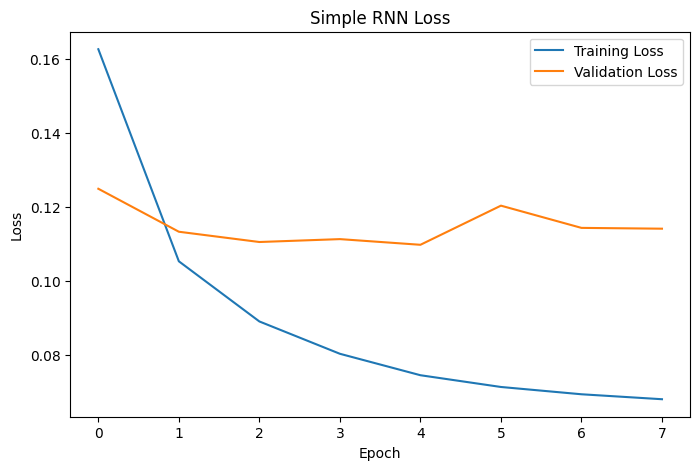

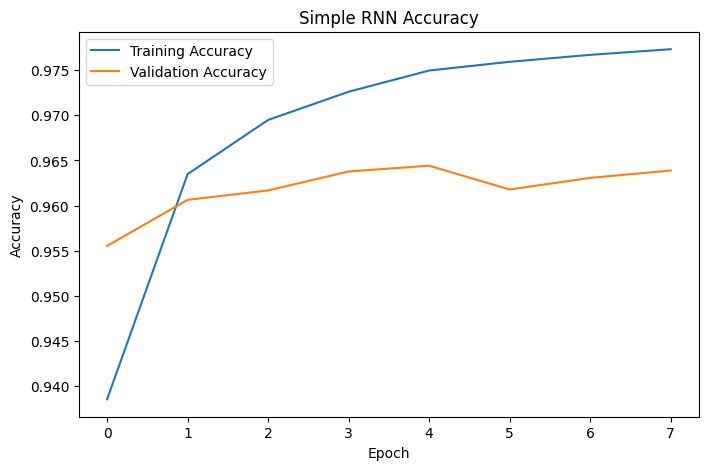

In [21]:
plot_training_history(rnn_history, "Simple RNN")

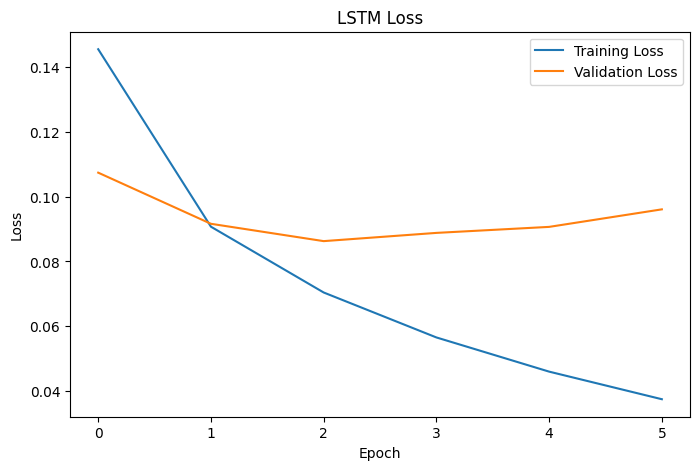

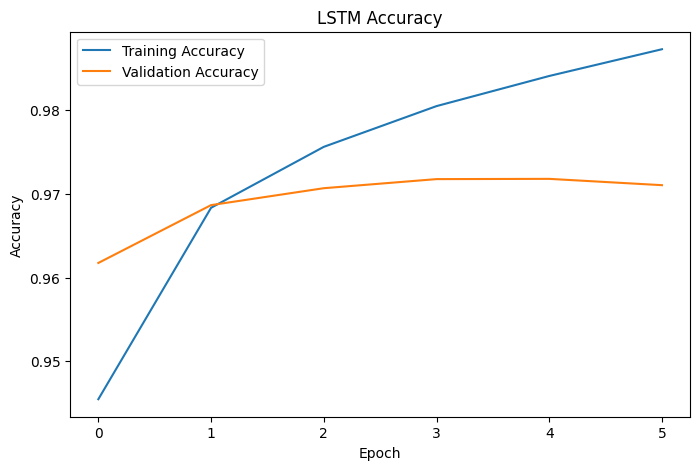

In [22]:
plot_training_history(lstm_history, "LSTM")

In [23]:
def predict_sentiment(text, model, tokenizer, max_len):
    cleaned_text = preprocess_text(text)

    sequence = tokenizer.texts_to_sequences([cleaned_text])

    padded_sequence = pad_sequences(
        sequence,
        maxlen=max_len,
        padding="post",
        truncating="post"
    )

    prediction_prob = model.predict(padded_sequence)[0][0]

    if prediction_prob > 0.5:
        prediction_class = 1
    else:
        prediction_class = 0

    return prediction_class, prediction_prob